### 1. Loading the Master Dataset

In [32]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Outputs/master_call_center_data.csv")
df.head()

,call_id,customer_id,agent_id_x,call_start_datetime,agent_assigned_datetime,call_end_datetime,call_transcript,AST_seconds,AHT_minutes,call_duration_minutes,...,call_reason_grouped,agent_id_y,agent_tone,customer_tone,average_sentiment,silence_percent_average,customer_tone_score,agent_tone_score,negative_customer_flag,high_silence_flag
0,4667960400,2033123310,963118,2024-07-31 23:56:00,2024-08-01 00:03:00,2024-08-01 00:34:00,\n\nAgent: Thank you for calling United Airlin...,420.0,31.0,38.0,...,Other,963118,neutral,angry,-0.04,0.39,-2,0,True,False
1,1122072124,8186702651,519057,2024-08-01 00:03:00,2024-08-01 00:06:00,2024-08-01 00:18:00,\n\nAgent: Thank you for calling United Airlin...,180.0,12.0,15.0,...,Booking,519057,calm,neutral,0.02,0.35,0,1,False,False
2,6834291559,2416856629,158319,2024-07-31 23:59:00,2024-08-01 00:07:00,2024-08-01 00:26:00,\n\nAgent: Thank you for calling United Airlin...,480.0,19.0,27.0,...,Irrops,158319,neutral,polite,-0.13,0.32,2,0,False,False
3,2266439882,1154544516,488324,2024-08-01 00:05:00,2024-08-01 00:10:00,2024-08-01 00:17:00,\n\nAgent: Thank you for calling United Airlin...,300.0,7.0,12.0,...,Upgrade,488324,neutral,frustrated,-0.20,0.20,-1,0,True,False
4,1211603231,5214456437,721730,2024-08-01 00:04:00,2024-08-01 00:14:00,2024-08-01 00:23:00,\n\nAgent: Thank you for calling United Airlin...,600.0,9.0,19.0,...,Seating,721730,neutral,polite,-0.05,0.35,2,0,False,False


### 2. Baseline Call Center Performance Metrics

In [3]:
baseline_metrics = {
    "Avg_AHT_minutes": df["AHT_minutes"].mean(),
    "Avg_AST_seconds": df["AST_seconds"].mean(),
    "Median_AHT_minutes": df["AHT_minutes"].median(),
    "Median_AST_seconds": df["AST_seconds"].median()
}

baseline_metrics

{'Avg_AHT_minutes': np.float64(11.813574442776629),
 'Avg_AST_seconds': np.float64(436.9732929281486),
 'Median_AHT_minutes': np.float64(7.5),
 'Median_AST_seconds': np.float64(420.0)}

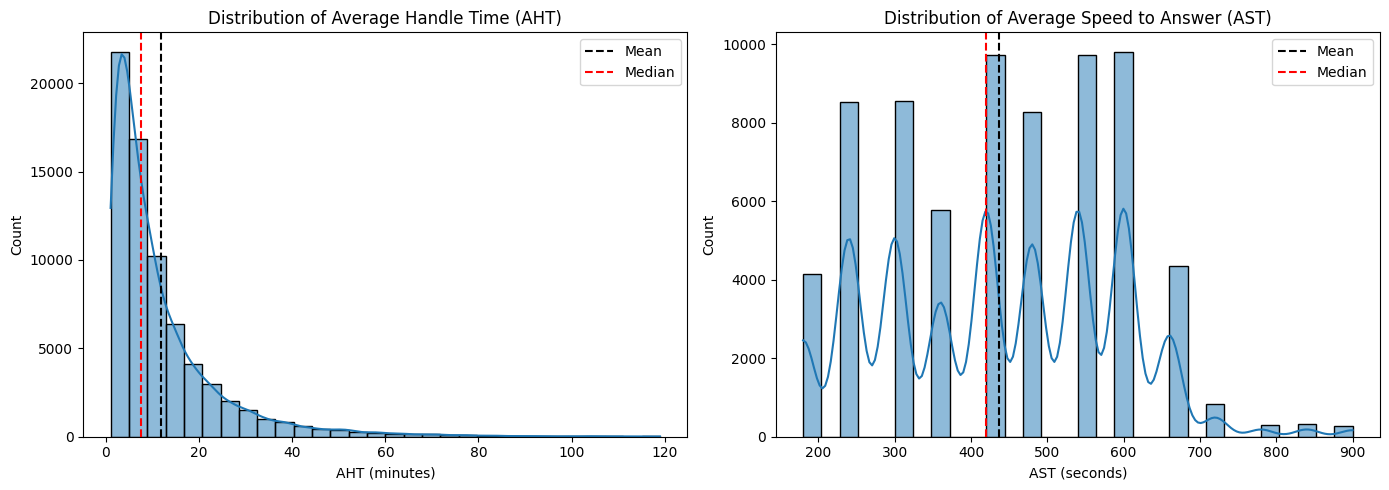

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["AHT_minutes"], bins=30, kde=True, ax=axes[0])
axes[0].axvline(df["AHT_minutes"].mean(), color="black", linestyle="--", label="Mean")
axes[0].axvline(df["AHT_minutes"].median(), color="red", linestyle="--", label="Median")
axes[0].set_title("Distribution of Average Handle Time (AHT)")
axes[0].set_xlabel("AHT (minutes)")
axes[0].legend()

sns.histplot(df["AST_seconds"], bins=30, kde=True, ax=axes[1])
axes[1].axvline(df["AST_seconds"].mean(), color="black", linestyle="--", label="Mean")
axes[1].axvline(df["AST_seconds"].median(), color="red", linestyle="--", label="Median")
axes[1].set_title("Distribution of Average Speed to Answer (AST)")
axes[1].set_xlabel("AST (seconds)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Insight:**

AHT is strongly right-skewed, meaning a small number of long calls drive inefficiency. AST is more tightly clustered with similar mean and median, indicating controlled queueing behavior. As a result, AHT requires targeted handling improvements, while AST depends on routing and queue optimization.

### 3. Defining High-Risk Calls

In [7]:
aht_threshold = df["AHT_minutes"].quantile(0.75)
ast_threshold = df["AST_seconds"].quantile(0.75)

df["high_aht_flag"] = (df["AHT_minutes"] >= aht_threshold).astype(int)
df["high_ast_flag"] = (df["AST_seconds"] >= ast_threshold).astype(int)

df[["high_aht_flag","high_ast_flag"]].head()

,high_aht_flag,high_ast_flag
0,1,0
1,0,0
2,1,0
3,0,0
4,0,1


In [27]:
overlap_counts = pd.crosstab(
    df["high_aht_flag"],
    df["high_ast_flag"]
)

overlap_counts

high_ast_flag,0,1
high_aht_flag,,
0,32608,19745
1,12378,5887


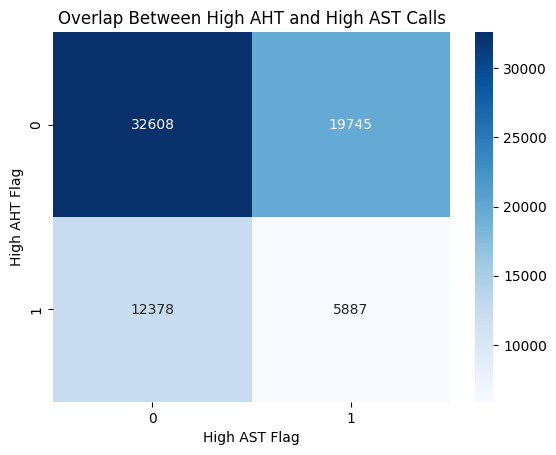

In [28]:
sns.heatmap(
    overlap_counts,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Overlap Between High AHT and High AST Calls")
plt.xlabel("High AST Flag")
plt.ylabel("High AHT Flag")
plt.show()

**Insight:**  
High AHT and high AST mostly occur in different calls, with limited overlap. High AST-only cases are more common, showing queue delays are a broader issue, while high AHT is driven by call-specific complexity. This supports modeling AHT and AST separately with targeted interventions.


### 4. Drivers of High AHT

In [13]:
# By Call Reason
df.groupby("call_reason_grouped")["high_aht_flag"].mean().sort_values(ascending=False)

call_reason_grouped
Mileage Plus             0.410857
Post-Flight              0.365468
Communications           0.318384
Irrops                   0.309851
Products And Services    0.293908
Other                    0.238904
Upgrade                  0.237972
Voluntary Change         0.229248
Seating                  0.133365
Booking                  0.121558
Baggage                  0.076864
Name: high_aht_flag, dtype: float64

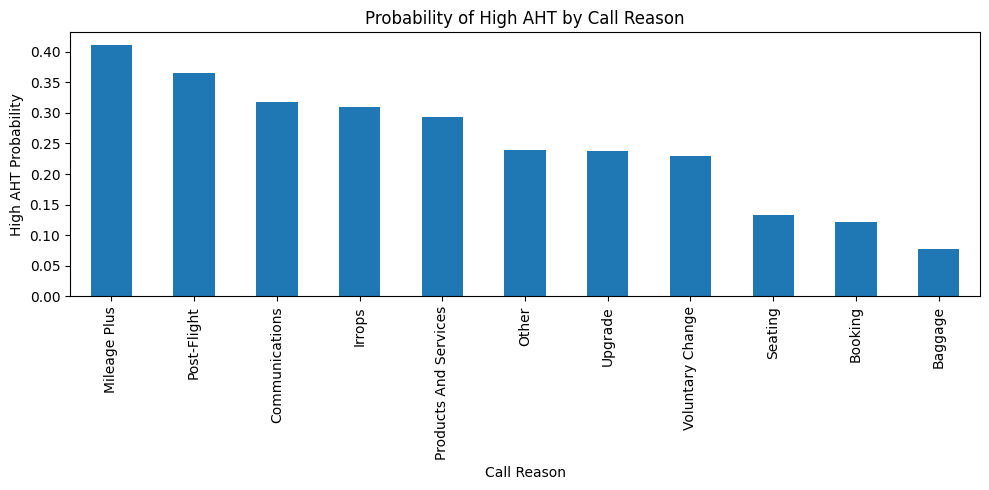

In [29]:
plt.figure(figsize=(10,5))
(
    df.groupby("call_reason_grouped")["high_aht_flag"]
      .mean()
      .sort_values(ascending=False)
      .plot(kind="bar")
)
plt.title("Probability of High AHT by Call Reason")
plt.ylabel("High AHT Probability")
plt.xlabel("Call Reason")
plt.tight_layout()
plt.show()


In [14]:
# By Silence
df.groupby("high_silence_flag")["high_aht_flag"].mean()

high_silence_flag
False    0.178057
True     0.484006
Name: high_aht_flag, dtype: float64

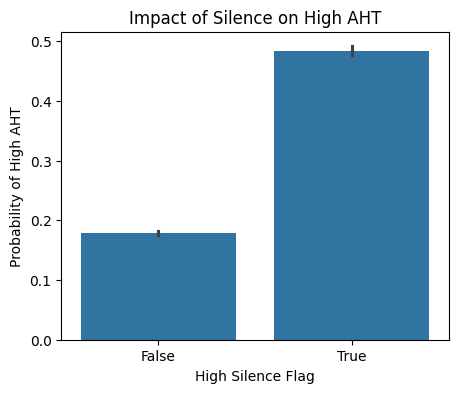

In [30]:
plt.figure(figsize=(5,4))
sns.barplot(
    x="high_silence_flag",
    y="high_aht_flag",
    data=df
)
plt.title("Impact of Silence on High AHT")
plt.xlabel("High Silence Flag")
plt.ylabel("Probability of High AHT")
plt.show()

In [15]:
# By Sentiment
df.groupby("negative_customer_flag")["high_aht_flag"].mean()

negative_customer_flag
False    0.259017
True     0.258085
Name: high_aht_flag, dtype: float64

**Insight:**  
Mileage Plus, Post-Flight, and IRROPS calls have the highest likelihood of long handle times, indicating issue complexity as a key driver of AHT. Calls with high silence are nearly three times more likely to result in high AHT, making silence a strong operational risk signal, while customer sentiment alone shows minimal direct impact.

### 5. Agent Tone and Call Efficiency

In [16]:
df.groupby("agent_tone_score")["AHT_minutes"].mean().sort_values(ascending=False)

agent_tone_score
 0    12.720516
-1    10.544949
 1    10.521398
-2     7.565089
 2     4.253333
Name: AHT_minutes, dtype: float64

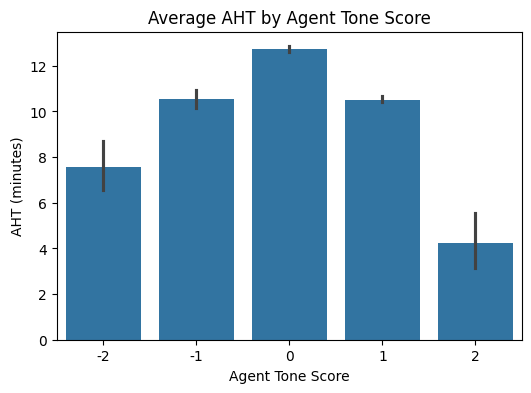

In [34]:
plt.figure(figsize=(6,4))
sns.barplot(
    x="agent_tone_score",
    y="AHT_minutes",
    data=df,
    estimator=np.mean
)
plt.title("Average AHT by Agent Tone Score")
plt.xlabel("Agent Tone Score")
plt.ylabel("AHT (minutes)")
plt.show()

In [17]:
tone_combo = (
    df.groupby(["customer_tone_score", "agent_tone_score"])["AHT_minutes"]
    .mean()
    .reset_index()
)
tone_combo

,customer_tone_score,agent_tone_score,AHT_minutes
0,-2,-2,8.753425
1,-2,-1,10.760839
2,-2,0,12.712369
3,-2,1,10.336877
4,-2,2,6.375000
5,-1,-2,7.873239
6,-1,-1,9.861373
7,-1,0,12.624970
8,-1,1,10.578144
9,-1,2,4.153846


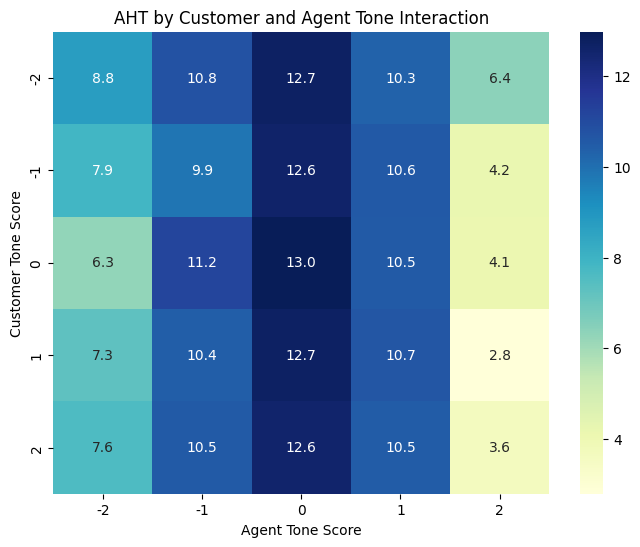

In [35]:
pivot = df.pivot_table(
    index="customer_tone_score",
    columns="agent_tone_score",
    values="AHT_minutes",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("AHT by Customer and Agent Tone Interaction")
plt.xlabel("Agent Tone Score")
plt.ylabel("Customer Tone Score")
plt.show()


**Insight:**  
Agent tone has a strong and consistent impact on handle time, with polite agents achieving the lowest AHT across all customer sentiment levels. Neutral agent responses lead to the longest calls regardless of customer tone, highlighting agent behavior as a controllable lever for reducing AHT.


### 6. Call Volume vs Efficiency

In [18]:
hourly_volume = df.groupby("call_hour").size()
high_volume_hours = hourly_volume[hourly_volume >= hourly_volume.quantile(0.8)].index

df["high_volume_hour"] = df["call_hour"].isin(high_volume_hours).astype(int)

df.groupby("high_volume_hour")["AHT_minutes"].mean()

high_volume_hour
0    11.830746
1    11.783850
Name: AHT_minutes, dtype: float64

**Insight:**  
Average handle time remains nearly unchanged between low- and high-volume hours, indicating that call handling efficiency does not degrade under load. This suggests that AHT issues are driven more by call complexity and handling strategy than by call volume alone.

### 7. Customer Tier Impact on Call Performance

In [19]:
df.groupby("elite_tier")[["AHT_minutes", "AST_seconds"]].mean()

,AHT_minutes,AST_seconds
elite_tier,,
High-Elite,12.988477,423.107989
Mid-Elite,11.897939,435.298284
Non-Elite,11.495339,441.107903


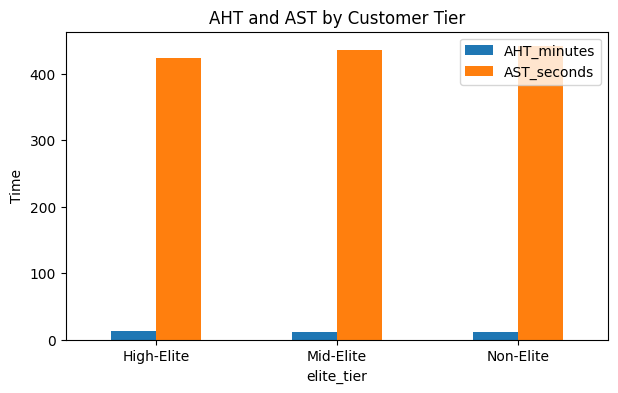

In [36]:
df.groupby("elite_tier")[["AHT_minutes", "AST_seconds"]].mean().plot(
    kind="bar",
    figsize=(7,4)
)
plt.title("AHT and AST by Customer Tier")
plt.ylabel("Time")
plt.xticks(rotation=0)
plt.show()


**Insight:**  
Customer tier shows only marginal differences in both AHT and AST, suggesting that call handling and queue assignment are largely uniform across tiers. Any prioritization effects appear subtle, indicating that customer tier alone is not a strong driver of call efficiency.


### 8. Creating a Composite High-Risk Call Label

In [21]:
df["high_risk_call"] = (
    (df["high_aht_flag"] == 1) |
    (df["high_ast_flag"] == 1) |
    (df["high_silence_flag"] == 1) |
    (df["negative_customer_flag"] == 1)
).astype(int)

In [22]:
df["high_risk_call"].value_counts(normalize=True)

high_risk_call
1    0.773684
0    0.226316
Name: proportion, dtype: float64

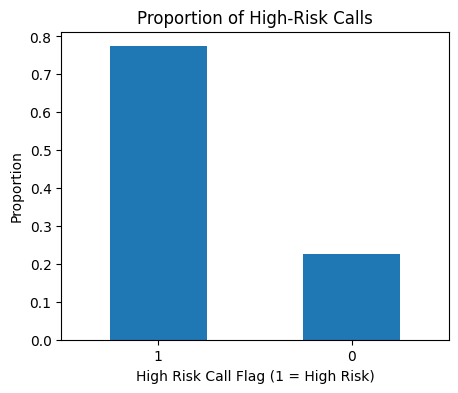

In [38]:
plt.figure(figsize=(5,4))
df["high_risk_call"].value_counts(normalize=True).plot(
    kind="bar"
)
plt.title("Proportion of High-Risk Calls")
plt.xlabel("High Risk Call Flag (1 = High Risk)")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

**Insight:**  
A large majority of calls (≈77%) meet at least one high-risk condition, indicating that risk factors are common in call center operations. This reinforces the need for predictive prioritization to distinguish truly critical calls rather than treating all calls uniformly.

In [40]:
df.to_csv("../Outputs/master_call_center_data_phase2.csv", index=False)

### Findings

1. Call center inefficiencies are driven by specific behavioral and operational factors rather than uniform performance degradation.

2. Average Handle Time (AHT) shows a strong right-skewed distribution, where a small subset of long calls disproportionately impacts overall efficiency, while Average Speed to Answer (AST) is more clustered, reflecting queueing and routing mechanisms rather than extreme delays.

3. High AHT and high AST largely affect different subsets of calls, with limited overlap. High AST-only cases are more prevalent, indicating queue delays as a broader issue, while high AHT is driven by call-specific complexity, justifying separate modeling and targeted interventions.

4. Mileage Plus, Post-Flight, and IRROPS calls have the highest likelihood of long handle times, identifying issue complexity as a key AHT driver. High silence calls are nearly three times more likely to result in high AHT, while customer sentiment alone shows minimal direct impact.

5. Agent tone is a strong efficiency lever: polite agent interactions consistently result in the lowest AHT across customer sentiment levels, while neutral agent responses lead to the longest calls. Agent behavior has a stronger influence on AHT than customer tone.

6. AHT remains nearly unchanged during high-volume hours, indicating that efficiency does not significantly deteriorate under load and is driven more by handling strategy than call volume.

7. Customer tier shows only marginal differences in AHT and AST, suggesting largely uniform handling practices and limited impact on call efficiency compared to behavioral and operational factors.

8. A majority of calls meet at least one high-risk condition, reinforcing the need for predictive prioritization to identify and manage truly critical calls rather than treating all calls uniformly.